In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

data = pd.DataFrame()
data = pd.read_csv("/content/cricket _match_data.csv (1).txt")
data

,Match_ID,Match_Date,Player_Name,Stadium
0,1001,2023-01-03,Virat Kohli,Wankhede Stadium Mumbai
1,1002,2023-01-07,Rohit Sharma,Eden Gardens Kolkata
2,1003,2023-01-12,MS Dhoni,Chepauk Stadium Chennai
3,1004,2023-01-15,KL Rahul,Chinnaswamy Stadium Bangalore
4,1005,2023-01-18,Hardik Pandya,Narendra Modi Stadium Ahmedabad
...,...,...,...,...
95,1096,2023-10-21,Jasprit Bumrah,Arun Jaitley Stadium Delhi
96,1097,2023-10-24,Ravindra Jadeja,PCA Stadium Mohali
97,1098,2023-10-27,Shubman Gill,Ekta Stadium Hyderabad
98,1099,2023-10-30,Suryakumar Yadav,Holkar Stadium Indore


In [ ]:
data.head()

,Match_ID,Match_Date,Player_Name,Stadium
0,1001,2023-01-03,Virat Kohli,Wankhede Stadium Mumbai
1,1002,2023-01-07,Rohit Sharma,Eden Gardens Kolkata
2,1003,2023-01-12,MS Dhoni,Chepauk Stadium Chennai
3,1004,2023-01-15,KL Rahul,Chinnaswamy Stadium Bangalore
4,1005,2023-01-18,Hardik Pandya,Narendra Modi Stadium Ahmedabad


In [ ]:
#Check shape
data.shape

(100, 4)

In [ ]:
#Check columns
data.columns

Index(['Match_ID', 'Match_Date', 'Player_Name', 'Stadium'], dtype='object')

In [ ]:
#Info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Match_ID     100 non-null    int64 
 1   Match_Date   100 non-null    object
 2   Player_Name  100 non-null    object
 3   Stadium      100 non-null    object
dtypes: int64(1), object(3)
memory usage: 3.3+ KB


In [ ]:
#Summary statistics
data.describe()

,Match_ID
count,100.000000
mean,1050.500000
std,29.011492
min,1001.000000
25%,1025.750000
50%,1050.500000
75%,1075.250000
max,1100.000000


In [ ]:
#Check missing values
data.isnull().sum()

,0
Match_ID,0
Match_Date,0
Player_Name,0
Stadium,0


In [23]:
#Check Duplicates
print("Duplicates:", data.duplicated().sum())
data.drop_duplicates(inplace=True)

Duplicates: 0


In [24]:
#Handle missing values - cricket version
data["Stadium"] = data["Stadium"].fillna("Unknown")
data["Player_Name"] = data["Player_Name"].fillna("Unknown")
print("Missing values after handling:")
data.isnull().sum()

Missing values after handling:


,0
Match_ID,0
Match_Date,0
Player_Name,0
Stadium,0


In [25]:

#Add Month column for analysis
data['Match_Date'] = pd.to_datetime(data['Match_Date'])
data['Month'] = data['Match_Date'].dt.month
data.head()

,Match_ID,Match_Date,Player_Name,Stadium,Month
0,1001,2023-01-03,Virat Kohli,Wankhede Stadium Mumbai,1
1,1002,2023-01-07,Rohit Sharma,Eden Gardens Kolkata,1
2,1003,2023-01-12,MS Dhoni,Chepauk Stadium Chennai,1
3,1004,2023-01-15,KL Rahul,Chinnaswamy Stadium Bangalore,1
4,1005,2023-01-18,Hardik Pandya,Narendra Modi Stadium Ahmedabad,1


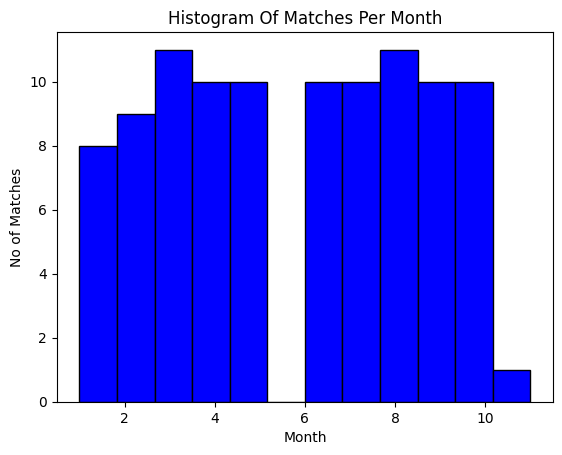

In [26]:
#Histogram - Matches per Month
plt.hist(data["Month"], edgecolor='black', color='blue', bins=12)
plt.title("Histogram Of Matches Per Month")
plt.xlabel("Month")
plt.ylabel("No of Matches")
plt.show()

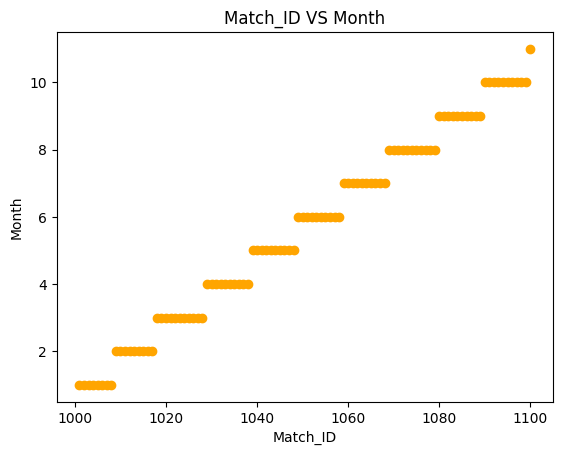

In [27]:
#Scatter Plot - Match_ID vs Month
plt.scatter(data["Match_ID"], data["Month"], color='orange')
plt.title("Match_ID VS Month")
plt.xlabel("Match_ID")
plt.ylabel("Month")
plt.show()

In [28]:
#Correlation - Match_ID and Month
correlation = data[["Match_ID", "Month"]].corr()
print(correlation)

          Match_ID     Month
Match_ID  1.000000  0.994851
Month     0.994851  1.000000


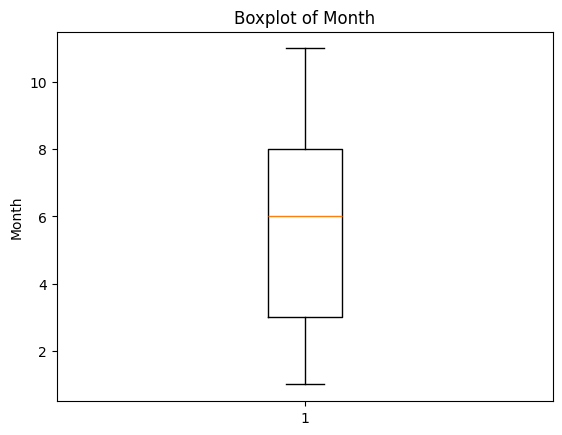

In [29]:
#Boxplot of Month
plt.boxplot(data["Month"])
plt.title("Boxplot of Month")
plt.ylabel("Month")
plt.show()

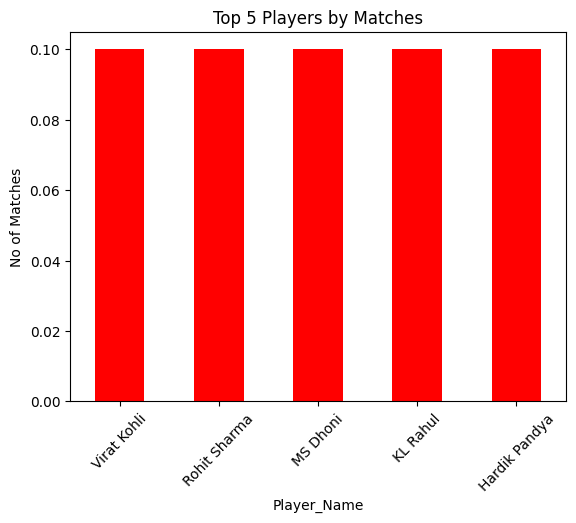

In [37]:
#Extra Analysis - Top Players
data['Player_Name'].value_counts(4).head(5).plot(kind='bar', color='red')
plt.title("Top 5 Players by Matches")
plt.ylabel("No of Matches")
plt.xticks(rotation=46)
plt.show()

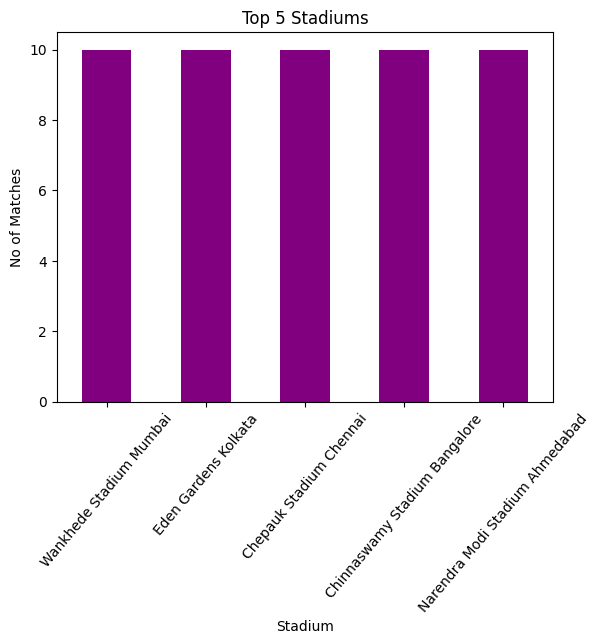

In [40]:

#Extra Analysis - Top Stadiums
data['Stadium'].value_counts().head(5).plot(kind='bar', color='purple')
plt.title("Top 5 Stadiums")
plt.ylabel("No of Matches")
plt.xticks(rotation=50)
plt.show()

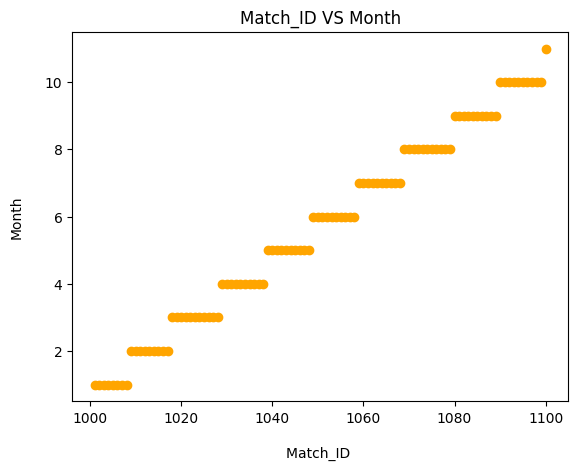

In [41]:
# Perform bivariate analysis - Analyze relationship
plt.scatter(data["Match_ID"], data["Month"], color='orange')
plt.title("Match_ID VS Month")
plt.xlabel("Match_ID ", labelpad=15)
plt.ylabel("Month", labelpad=15)
plt.show()

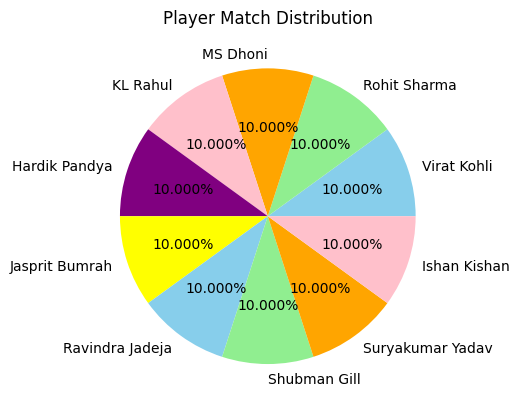

In [46]:

# PAGE : Data Visualization - Pie Chart
# Kuthlya Player ne saglyat jast matches khelale

plt.pie(
data["Player_Name"].value_counts(),
labels=data["Player_Name"].value_counts().index,
autopct="%4.3f%%",
colors=["skyblue", "lightgreen", "orange", "pink", "purple", "yellow"]
)
plt.title("Player Match Distribution")
plt.show()